# Chatbot with Retrieval Augmented Generation
https://python.langchain.com/docs/tutorials/qa_chat_history/

Conversational experiences can be naturally represented using a sequence of messages. In addition to messages from the user and assistant, retrieved documents and other artifacts can be incorporated into a message sequence via [tool messages](https://python.langchain.com/docs/concepts/messages/#toolmessage). This motivates us to represent the state of our RAG application using a sequence of messages. Specifically, we will have

1. User input as a HumanMessage;
2. Vector store query as an AIMessage with tool calls;
3. Retrieved documents as a ToolMessage;
4. Final response as a AIMessage.

In [ ]:
!pip show langchain

Name: langchain
Version: 0.3.13
Summary: Building applications with LLMs through composability
Home-page: https://github.com/langchain-ai/langchain
Author: 
Author-email: 
License: MIT
Location: /Users/manuelalejandroquesada/miniconda3/envs/langchain_env/lib/python3.12/site-packages
Requires: aiohttp, langchain-core, langchain-text-splitters, langsmith, numpy, pydantic, PyYAML, requests, SQLAlchemy, tenacity
Required-by: 


In [107]:
# ! pip install langchain-core langgraph>0.2.27 ollama python-dotenv


from langchain_ollama.chat_models import ChatOllama
from langchain_ollama.embeddings import OllamaEmbeddings
from dotenv import load_dotenv, find_dotenv
import os
import warnings
from IPython.display import display, Markdown
from langchain_openai import ChatOpenAI, OpenAIEmbeddings  # to see better the output text

warnings.filterwarnings("ignore")
_ = load_dotenv(find_dotenv())  # read local .env file

os.environ["LANGCHAIN_TRACING_V2"] = "true"

# ! pip install langchain_ollama

# at this moment, the following models don't support tools
# llm = ChatOllama(
#     model="gemma2:2b",
#     temperature=0.1,
# )

# # 1024 dimension embeddings
# embeddings = OllamaEmbeddings(model="mxbai-embed-large")

llm = ChatOpenAI(model="gpt-4o-mini")
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")


## Store the documents

In [108]:
# %%capture --no-stderr
# %pip install --upgrade --quiet langgraph langchain-community beautifulsoup4

In [109]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)

In [110]:
import bs4
from langchain import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing_extensions import List, TypedDict

# Load and chunk contents of the blog
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

# Index chunks
_ = vector_store.add_documents(documents=all_splits)

## Retrieval into a tool
https://python.langchain.com/docs/how_to/custom_tools/

Build the tool to retrieve the relevants docs

In [111]:
from langchain_core.tools import tool

# If "content_and_artifact" then the output is expected to be a two-tuple
# corresponding to the (content, artifact) of a ToolMessage.
@tool(response_format="content_and_artifact")
def retrieve(query: str):
    """Retrieve information related to a query."""
    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

## Prepare the functions that represent the nodes in the graph

In [112]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode
from langgraph.graph import MessagesState, StateGraph


graph_builder = StateGraph(MessagesState)

# Step 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state["messages"])
    # MessagesState appends messages to state instead of overwriting
    return {"messages": [response]}


# Step 2: Execute the retrieval.
tools = ToolNode([retrieve],name="retrieve_tool")


# Step 3: Generate a response using the retrieved content.
def generate(state: MessagesState):
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run
    response = llm.invoke(prompt)
    return {"messages": [response]}

## Build the graph

In [113]:
from langgraph.graph import END
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "retrieve_tool"},
)
graph_builder.add_edge("retrieve_tool", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

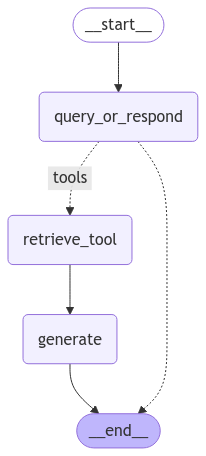

In [114]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [115]:
input_message = "Hello"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I assist you today?


In [116]:
input_message = "What is Task Decomposition?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_ewZjQDemAw8b1teHKKAb752L)
 Call ID: call_ewZjQDemAw8b1teHKKAb752L
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Fig. 1. Overview of a LLM-powered autonomous agent system.
Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms b

## Add memory
LangGraph comes with a simple in-memory checkpointer, which we use below.

In [117]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}}

In [118]:
input_message = "What is Task Decomposition?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_kX1BHDD82TeWozI0XFFKbgUv)
 Call ID: call_kX1BHDD82TeWozI0XFFKbgUv
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Fig. 1. Overview of a LLM-powered autonomous agent system.
Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms b

## See the history

In [119]:
for message in graph.get_state(config).values['messages']:
    print(message.pretty_print())

================================ Human Message =================================

What is Task Decomposition?
None
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_kX1BHDD82TeWozI0XFFKbgUv)
 Call ID: call_kX1BHDD82TeWozI0XFFKbgUv
  Args:
    query: Task Decomposition
None
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Fig. 1. Overview of a LLM-powered autonomous agent system.
Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT tr

In [120]:
input_message = "So, what is the importance of Task Decomposition?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

So, what is the importance of Task Decomposition?
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_l5UGwh1BeSyYP2nxbU4Ub5YB)
 Call ID: call_l5UGwh1BeSyYP2nxbU4Ub5YB
  Args:
    query: importance of Task Decomposition
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Fig. 1. Overview of a LLM-powered autonomous agent system.
Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller

## See the history again

In [121]:
for message in graph.get_state(config).values['messages']:
    print(message.pretty_print())

================================ Human Message =================================

What is Task Decomposition?
None
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_kX1BHDD82TeWozI0XFFKbgUv)
 Call ID: call_kX1BHDD82TeWozI0XFFKbgUv
  Args:
    query: Task Decomposition
None
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Fig. 1. Overview of a LLM-powered autonomous agent system.
Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT tr

# Using Agents

in this case, we can do this in one line using LangGraph's pre-built ReAct agent constructor, 

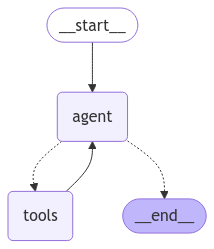

In [122]:
from langgraph.prebuilt import create_react_agent

# Creates a graph that works with a chat model that utilizes tool calling.
agent_executor = create_react_agent(llm, [retrieve], checkpointer=memory)
display(Image(agent_executor.get_graph().draw_mermaid_png()))

The key difference from our earlier implementation is that instead of a final generation step that ends the run, here the tool invocation loops back to the original LLM call. The model can then either answer the question using the retrieved context, or generate another tool call to obtain more information.

Let's test this out. We construct a question that would typically require an iterative sequence of retrieval steps to answer:

In [123]:
config = {"configurable": {"thread_id": "def234"}}

input_message = (
    "What is the standard method for Task Decomposition?\n\n"
    "Once you get the answer, look up common extensions of that method."
)

for event in agent_executor.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the standard method for Task Decomposition?

Once you get the answer, look up common extensions of that method.
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_QBSmzttlvDwZ25xt5h2iCQ6m)
 Call ID: call_QBSmzttlvDwZ25xt5h2iCQ6m
  Args:
    query: standard method for Task Decomposition
  retrieve (call_3UA82d6W2lV6sqXFvBckjG8Y)
 Call ID: call_3UA82d6W2lV6sqXFvBckjG8Y
  Args:
    query: common extensions of Task Decomposition method
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Tree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure

In [124]:
config = {"configurable": {"thread_id": "def234"}}

input_message = (
    "hello, my name is manuel"
)

for event in agent_executor.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

hello, my name is manuel
================================== Ai Message ==================================

Hello Manuel! How can I assist you today?


In [125]:
config = {"configurable": {"thread_id": "def234"}}

input_message = (
    "Tell me my name and the resume about the task decomposition that I asked before"
)

for event in agent_executor.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Tell me my name and the resume about the task decomposition that I asked before
================================== Ai Message ==================================

Your name is Manuel. 

### Summary of Task Decomposition

Task decomposition is a method used to break down complex tasks into smaller, manageable steps. A prominent technique in this area is the **Chain of Thought (CoT)** approach, which enhances model performance on intricate tasks by instructing models to "think step by step." This method allows for more computational resources at test time, transforming challenging tasks into simpler components. 

**Ways to Achieve Task Decomposition**:
1. **Prompting with Language Models (LLMs)**: Using simple prompts like "Steps for XYZ" or "What are the subgoals for achieving XYZ?"
2. **Task-Specific Instructions**: Tailored instructions for specific tasks, such as "Write a story outline."
3. **Human Input

Partial remarks
* With the agents, the chatbot works well with the retrieve tool, allowing it to make many retrieval questions. It needs to include the trimmer to control the chat history passed to the model.

* To build it, we need to use Langgraph; in this case, it requires a step of research and testing to understand how to build the graph and the tools to use. Additionally, the graph can be saved in memory, but it needs to be saved in SQLite or Postgresql database (natively supported by Langgraph).

* The open-source models (phi, llama, gemma) don't support tools, so the chatbot can't be built with them.

* Alternatively, we can have a chat history with the chatbot. So, the retrieved docs will be inserted into the prompt for a specific question. We lost the ability to decide when to use the retrieve tool or the model directly.

